In [21]:
import pandas as pd 
import json
import matplotlib.pyplot as plt
import time 
import re
from typing import Optional, Set
import numpy as np
from collections import defaultdict
import sys, os
ROOT = "/Users/fserracrespi/Desktop/PD_PROJECT_UOFL" 
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from utils.Decode import decoder_DF
from utils.dataframe_cols import cols_asignacion
from scipy.stats import kurtosis, skew
import math

In [22]:
path2='/Users/fserracrespi/Desktop/PD_Project_UofL/DATA_COLLECTION/12_09_2025/Study_Docs/Data___Databases/DATA/Data_Dictionary_-_Harmonized_12Sep2025.csv'
path3='/Users/fserracrespi/Desktop/PD_Project_UofL/DATA_COLLECTION/12_09_2025/Study_Docs/Data___Databases/DATA/Code_List_-_Harmonized_12Sep2025.csv'
code_cols=pd.read_csv(path2, dtype=str)
code_rows=pd.read_csv(path3, dtype=str)

In [23]:
matrix_presence=pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/DATA_COLLECTION/DATA_COLLECTION_STRUCTURE/PATNO_presence_matrix.csv')
print(f'Shape Presence Matrix{matrix_presence.shape}') # this matrix is filtred by PATNOs in UPDRSIII motor assessment
print(f'Duplicated presence matrix rows: {matrix_presence.duplicated().sum()}')

cohort_patno=pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/DATA_COLLECTION/12_09_2025/Subject Characteristics/Patient_Status/DATA/Participant_Status_12Sep2025.csv')
print(f'Shape Cohort Patno {cohort_patno.shape}')
print(f'Duplicated cohort patno rows: {cohort_patno.duplicated().sum()}')
cohort_patno=decoder_DF(cohort_patno, code_rows, code_cols, module='PATIENT_STATUS')[['PATNO','Enrollment Cohort']]
cohort_patno=cohort_patno.loc[cohort_patno['Enrollment Cohort']=="Parkinson's Disease"]
print(f'Cohort Patno after filtering Parkinsons {cohort_patno.shape}')

Shape Presence Matrix(4544, 203)
Duplicated presence matrix rows: 0
Shape Cohort Patno (7538, 27)
Duplicated cohort patno rows: 0
Cohort Patno after filtering Parkinsons (1927, 2)


/Users/fserracrespi/Desktop/PD_PROJECT_UOFL/utils/Decode.py:81: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace('NaN', np.nan, inplace=True)


In [24]:
matrix_presence['PATNO']=matrix_presence['PATNO'].astype(str)
cohort_patno['PATNO']=cohort_patno['PATNO'].astype(str)

In [25]:
matrix_presence=matrix_presence.merge(cohort_patno, on='PATNO', how='inner')
print(f'Presence matrix after merging with cohort patno {matrix_presence.shape}')
matrix_presence=matrix_presence.drop(columns=['Enrollment Cohort'])
print(f'Duplicated presence matrix rows after merging with cohort patno: {matrix_presence.duplicated().sum()}')

Presence matrix after merging with cohort patno (1546, 204)
Duplicated presence matrix rows after merging with cohort patno: 0


In [26]:
summary_presence=matrix_presence.sum()
summary_presence=summary_presence.drop(labels=['PATNO'])
summary_presence=pd.DataFrame(summary_presence)
summary_presence.reset_index(inplace=True)
summary_presence.rename(columns={'index':'Docs'}, inplace=True)
summary_presence.rename(columns={0:'Count'}, inplace=True)
summary_presence=summary_presence.sort_values(by='Count', ascending=False)
summary_presence=summary_presence.loc[summary_presence['Count']>0]
summary_presence['Percentage']=(summary_presence['Count']/matrix_presence.shape[0])*100
summary_presence['Percentage'] = pd.to_numeric(summary_presence['Percentage'], errors='coerce')
summary_presence['Percentage_rounded']=summary_presence['Percentage'].round()
summary_presence.head()

,Docs,Count,Percentage,Percentage_rounded
0,MDS-UPDRS_Part_III_12Sep2025.csv,1546,100.000000,100.0
199,Demographics_12Sep2025.csv,1546,100.000000,100.0
195,Participant_Status_12Sep2025.csv,1546,100.000000,100.0
56,Documentation_of_Informed_Consent_12Sep2025.csv,1546,100.000000,100.0
200,Socio-Economics_12Sep2025.csv,1545,99.935317,100.0


In [27]:
SC_dict = {'Family history':['Family_History_12Sep2025.csv'],
            'Genetic Status ':['iu_genetic_consensus_20250515_12Sep2025.csv','PPMI_PD_Variants_Genetic_Status_WGS_20180921.csv','PPMI_Project_9001_20250624_12Sep2025.csv'],
            'Demographics':['Demographics_12Sep2025.csv'],
            'Socio-economics':['Socio-Economics_12Sep2025.csv'],
            'Falls history':['History_of_Falls_Baseline__Online__12Sep2025.csv','History_of_Falls_Surveillance__Online__12Sep2025.csv','Determination_of_Freezing_and_Falls_12Sep2025.csv'],
            'Age at Visit':['Age_at_visit_12Sep2025.csv'],
            'Head injury history':['Head_Injuries__Online__12Sep2025.csv'],
            'Subject cohort history':['Subject_Cohort_History_12Sep2025.csv'],
            'Participant status':['Participant_Status_12Sep2025.csv'],
            'Caffeine consumption':['Caffeine_Consumption__Online__12Sep2025.csv'],
            'COVID-19 history':['COVID-19_History__Online__12Sep2025.csv','COVID-19_History_Part_2__Online__12Sep2025.csv'],
            'Smoking history':['Smoking_History__Online__12Sep2025.csv'],
            'Physical activity':['Physical_Activity__Online__13Sep2025.csv'],
            'Chemical exposure':['Chemical_Exposure__Online__13Sep2025.csv']
}

mh_dict = {'Neurological exams':['Neurological_Exam_12Sep2025.csv'],
            'Safety monitoring':['Adverse_Event_Log_12Sep2025.csv','Adverse_Event_Telephone_Assessment_12Sep2025.csv','Adverse_Event_In-Clinic_Assessment_12Sep2025.csv'],
            'Vital signs':['Vital_Signs_12Sep2025.csv'],
            'Pregnancy':['Pregnancy_Test_12Sep2025.csv'],
            'Medication':['Concomitant_Medication_Log_12Sep2025.csv','LEDD_Concomitant_Medication_Log_12Sep2025.csv','Medical_Conditions_Log_12Sep2025.csv'],
            'General physical exams':['General_Physical_Exam_12Sep2025.csv','Features_of_Parkinsonism_12Sep2025.csv','Clinical_Diagnosis_12Sep2025.csv'],
}

ma_dict = {'MDS-UPDRS':['MDS-UPDRS_Part_I_12Sep2025.csv','MDS_UPDRS_Part_II__Patient_Questionnaire_12Sep2025.csv',
                        'MDS-UPDRS_Part_I_Patient_Questionnaire_12Sep2025.csv','MDS-UPDRS_Part_III_12Sep2025.csv',
                        'MDS-UPDRS_Part_IV__Motor_Complications_12Sep2025.csv'],
            'Neuro QoL Motor':['Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_12Sep2025.csv','Neuro_QoL__Upper_Extremity_Function_-_Short_Form_12Sep2025.csv'],
            'Modified schwab':['Modified_Schwab___England_Activities_of_Daily_Living_12Sep2025.csv'],
            'Gait':['Gait_Substudy_Gait_Mobility_Assessment_and_Measurement_12Sep2025.csv'],
            'Arm swing':['Gait_Data___Arm_swing__Opals__12Sep2025.csv','Gait_Data___Arm_swing__Axivity__12Sep2025.csv'],
            'Function Questionnaire':['Participant_Motor_Function_Questionnaire_12Sep2025.csv'],
}

noma_dict = {'MoCA':['Montreal_Cognitive_Assessment__MoCA__12Sep2025.csv'],
            'SCOPA-AUT':['SCOPA-AUT_12Sep2025.csv'],
            'Benton Judgement of Line Orientation':['Benton_Judgement_of_Line_Orientation_12Sep2025.csv'],
            'Clock drawing':['Clock_Drawing_12Sep2025.csv'],
            'Semnatic fluency':['Modified_Semantic_Fluency_12Sep2025.csv'],
            'Letter number sequencing':['Letter_-_Number_Sequencing_12Sep2025.csv'],
            'Symbol digit modalities':['Symbol_Digit_Modalities_Test_12Sep2025.csv'],
            'Trail making A and B':['Trail_Making_A_and_B_12Sep2025.csv'],
            'Neuro QoL Non motor':['Neuro_QoL__Cognition_Function_-_Short_Form_12Sep2025.csv','Neuro_QoL__Communication_-_Short_Form_12Sep2025.csv'],
            'PDAQ-27':['PDAQ-27_12Sep2025.csv'],
            'REM Sleep Disorder':['REM_Sleep_Behavior_Disorder_Questionnaire_12Sep2025.csv'],
            'Epworth Sleepiness Scale ':['Epworth_Sleepiness_Scale_12Sep2025.csv']
}

list_MUST_dics = [x for d in [SC_dict, mh_dict, ma_dict, noma_dict] for v in d.values() for x in v]
print(f'Number of MUST files: {len(list_MUST_dics)}')


Number of MUST files: 56


In [28]:
MUST_summary_presence=summary_presence.loc[summary_presence['Docs'].isin(list_MUST_dics),:]
MUST_summary_presence

,Docs,Count,Percentage,Percentage_rounded
0,MDS-UPDRS_Part_III_12Sep2025.csv,1546,100.000000,100.0
199,Demographics_12Sep2025.csv,1546,100.000000,100.0
195,Participant_Status_12Sep2025.csv,1546,100.000000,100.0
200,Socio-Economics_12Sep2025.csv,1545,99.935317,100.0
147,Vital_Signs_12Sep2025.csv,1543,99.805951,100.0
156,MDS_UPDRS_Part_II__Patient_Questionnaire_12Sep...,1543,99.805951,100.0
155,MDS-UPDRS_Part_I_Patient_Questionnaire_12Sep20...,1543,99.805951,100.0
148,Neurological_Exam_12Sep2025.csv,1543,99.805951,100.0
198,Age_at_visit_12Sep2025.csv,1543,99.805951,100.0
173,Montreal_Cognitive_Assessment__MoCA__12Sep2025...,1542,99.741268,100.0


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_85605/1347652217.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MUST_summary_presence["Percentage_Range"] = pd.cut(


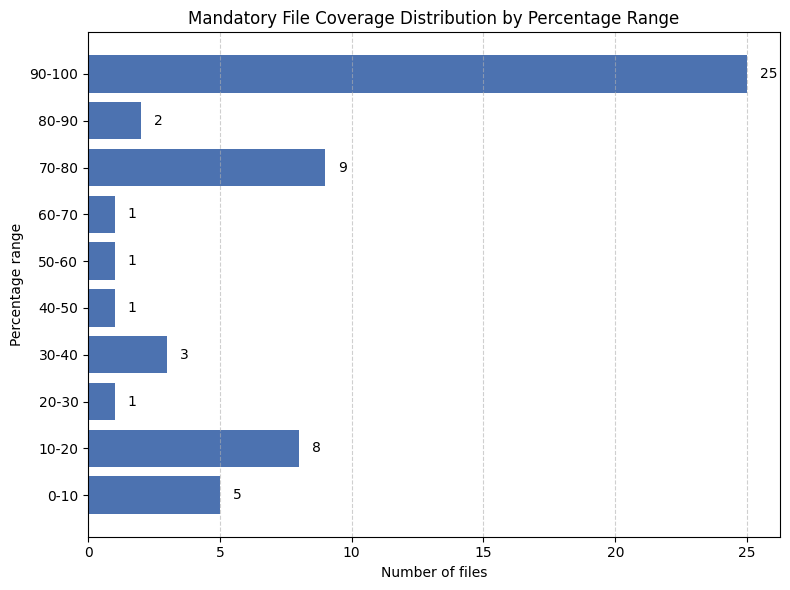

In [29]:


# Create percentage bins (intervals)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50",
          "50-60", "60-70", "70-80", "80-90", "90-100"]

# Create a new column with percentage ranges
MUST_summary_presence["Percentage_Range"] = pd.cut(
    MUST_summary_presence["Percentage"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count how many files fall in each range
distribution = MUST_summary_presence["Percentage_Range"].value_counts().sort_index()

# --- Horizontal bar chart ---
plt.figure(figsize=(8,6))
bars = plt.barh(distribution.index, distribution.values, color="#4C72B0")
plt.xlabel("Number of files")
plt.ylabel("Percentage range")
plt.title("Mandatory File Coverage Distribution by Percentage Range")

# Add value labels at the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,               # X position (just beyond bar end)
        bar.get_y() + bar.get_height()/2,    # Y position (vertically centered)
        str(int(bar.get_width())),           # value label
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [30]:
MUST_summary_presence
MUST_range_dict = {"0-10":[], "10-20":[], "20-30":[], "30-40":[], "40-50":[],
          "50-60":[], "60-70":[], "70-80":[], "80-90":[], "90-100":[]}

for idx, row in MUST_summary_presence.iterrows():
    range_label = row["Percentage_Range"]
    MUST_range_dict[range_label].append(row["Docs"])

    

# Listado de archivos por rango

| **Rango**     | **Archivos** |
|------------|--------------|
| **0–10** | Pregnancy_Test_12Sep2025.csv, COVID-19_History_Part_2__Online__12Sep2025.csv, Gait_Data___Arm_swing__Opals__12Sep2025.csv, Gait_Substudy_Gait_Mobility_Assessment_and_Measurement_12Sep2025.csv, Gait_Data___Arm_swing__Axivity__12Sep2025.csv |
| **10–20** | History_of_Falls_Baseline__Online__12Sep2025.csv, COVID-19_History__Online__12Sep2025.csv, History_of_Falls_Surveillance__Online__12Sep2025.csv, Caffeine_Consumption__Online__12Sep2025.csv, Head_Injuries__Online__12Sep2025.csv, Smoking_History__Online__12Sep2025.csv, Chemical_Exposure__Online__13Sep2025.csv, Physical_Activity__Online__13Sep2025.csv |
| **20–30** | Subject_Cohort_History_12Sep2025.csv |
| **30–40** | Adverse_Event_Log_12Sep2025.csv, PDAQ-27_12Sep2025.csv, PPMI_PD_Variants_Genetic_Status_WGS_20180921.csv |
| **40–50** | PPMI_Project_9001_20250624_12Sep2025.csv |
| **50–60** | Adverse_Event_In-Clinic_Assessment_12Sep2025.csv |
| **60–70** | Clinical_Diagnosis_12Sep2025.csv |
| **70–80** | Determination_of_Freezing_and_Falls_12Sep2025.csv, Neuro_QoL__Cognition_Function_-_Short_Form_12Sep2025.csv, Neuro_QoL__Communication_-_Short_Form_12Sep2025.csv, Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_12Sep2025.csv, Neuro_QoL__Upper_Extremity_Function_-_Short_Form_12Sep2025.csv, Clock_Drawing_12Sep2025.csv, Trail_Making_A_and_B_12Sep2025.csv, Participant_Motor_Function_Questionnaire_12Sep2025.csv, Medical_Conditions_Log_12Sep2025.csv |
| **80–90** | LEDD_Concomitant_Medication_Log_12Sep2025.csv, MDS-UPDRS_Part_IV__Motor_Complications_12Sep2025.csv |
| **90–100** | MDS-UPDRS_Part_III_12Sep2025.csv, Demographics_12Sep2025.csv, Participant_Status_12Sep2025.csv, Socio-Economics_12Sep2025.csv, Vital_Signs_12Sep2025.csv, MDS_UPDRS_Part_II__Patient_Questionnaire_12Sep2025.csv, MDS-UPDRS_Part_I_Patient_Questionnaire_12Sep2025.csv, Neurological_Exam_12Sep2025.csv, Age_at_visit_12Sep2025.csv, Montreal_Cognitive_Assessment__MoCA__12Sep2025.csv, MDS-UPDRS_Part_I_12Sep2025.csv, Modified_Schwab___England_Activities_of_Daily_Living_12Sep2025.csv, General_Physical_Exam_12Sep2025.csv, Family_History_12Sep2025.csv, Adverse_Event_Telephone_Assessment_12Sep2025.csv, SCOPA-AUT_12Sep2025.csv, REM_Sleep_Behavior_Disorder_Questionnaire_12Sep2025.csv, Epworth_Sleepiness_Scale_12Sep2025.csv, Modified_Semantic_Fluency_12Sep2025.csv, Letter_-_Number_Sequencing_12Sep2025.csv, Benton_Judgement_of_Line_Orientation_12Sep2025.csv, Symbol_Digit_Modalities_Test_12Sep2025.csv, Features_of_Parkinsonism_12Sep2025.csv, Concomitant_Medication_Log_12Sep2025.csv, iu_genetic_consensus_20250515_12Sep2025.csv |


sub-estudios y estudios generales 
- subestudios: online/gait/WGS/9001
- pregancy Test just for women 
- MDS-UPDRS 5 gente con dyskinesia
- Adverse events si no esta en el csv es que no ha tenido 
- medicaciones si no esta no toma 


In [31]:
matrix_presence_MUST=matrix_presence[['PATNO'] + list_MUST_dics]
print(f'Shape MUST presence matrix: {matrix_presence_MUST.shape}')
Online_cols = matrix_presence_MUST.filter(like='Online').columns.tolist()
Gait_cols = matrix_presence_MUST.filter(like='Gait').columns.tolist()
print(f'Number of Online cols: {len(Online_cols)}')
print(f'Number of Gait cols: {len(Gait_cols)}')
matrix_presence_MUST = matrix_presence_MUST.drop(columns=Online_cols + Gait_cols+
                                                ['PPMI_Project_9001_20250624_12Sep2025.csv','PPMI_PD_Variants_Genetic_Status_WGS_20180921.csv',
                                                'Subject_Cohort_History_12Sep2025.csv','Adverse_Event_Log_12Sep2025.csv','Adverse_Event_In-Clinic_Assessment_12Sep2025.csv',
                                                'Pregnancy_Test_12Sep2025.csv','LEDD_Concomitant_Medication_Log_12Sep2025.csv', 'MDS-UPDRS_Part_IV__Motor_Complications_12Sep2025.csv',
                                                'iu_genetic_consensus_20250515_12Sep2025.csv','Concomitant_Medication_Log_12Sep2025.csv','PDAQ-27_12Sep2025.csv','Adverse_Event_Telephone_Assessment_12Sep2025.csv',
                                                'Medical_Conditions_Log_12Sep2025.csv'])


Shape MUST presence matrix: (1546, 57)
Number of Online cols: 9
Number of Gait cols: 3


In [32]:

# Asegurarse de que la primera columna sea el identificador
id_col = "PATNO"

# Seleccionar solo las columnas booleanas (todas excepto PATNO)
bool_cols = [col for col in matrix_presence_MUST.columns if col != id_col]

# Calcular número de True y False por fila
matrix_presence_MUST['Num_True'] = matrix_presence_MUST[bool_cols].sum(axis=1)
matrix_presence_MUST['Num_False'] = matrix_presence_MUST[bool_cols].shape[1] - matrix_presence_MUST['Num_True']

# Crear una columna con los nombres de archivos que son False
matrix_presence_MUST['Archivos_False'] = matrix_presence_MUST[bool_cols].apply(
    lambda row: [col for col, val in row.items() if not val], axis=1
)

# Dejar solo las columnas finales
resultado = matrix_presence_MUST[[id_col, 'Num_True', 'Num_False', 'Archivos_False']]

# Porcentajes de True
resultado['Percentage_T'] = resultado['Num_True'] / (resultado['Num_True'] + resultado['Num_False']) * 100
resultado=resultado.sort_values(by='Percentage_T', ascending=False)
resultado.head()

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_85605/538568295.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resultado['Percentage_T'] = resultado['Num_True'] / (resultado['Num_True'] + resultado['Num_False']) * 100


,PATNO,Num_True,Num_False,Archivos_False,Percentage_T
0,100001,31,0,[],100.0
771,312859,31,0,[],100.0
781,313702,31,0,[],100.0
779,313373,31,0,[],100.0
777,3132,31,0,[],100.0


In [33]:
Patno_full_MUST = resultado.loc[resultado['Num_False'] == 0, 'PATNO'].tolist()
print(f'Number of PATNOs with full MUST data: {len(Patno_full_MUST)}')


Number of PATNOs with full MUST data: 1056


In [34]:
matrix_presence_MUST=matrix_presence_MUST.drop(columns=['Num_True', 'Num_False', 'Archivos_False'])
matrix_presence_MUST_full = matrix_presence_MUST.loc[matrix_presence_MUST['PATNO'].isin(Patno_full_MUST), :]
print(f'Shape MUST presence matrix with full data: {matrix_presence_MUST_full.shape}')


Shape MUST presence matrix with full data: (1056, 32)


In [35]:
matrix_presence_MUST_full.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_CSV_CLEAN/Relevant_presnece_PATNO', index=False)

# not obligatory data


In [36]:
print(f'Shape original presence matrix: {matrix_presence.shape}')

Shape original presence matrix: (1546, 203)


In [37]:
presence_matrix_additional = matrix_presence.drop(columns=list_MUST_dics)
presence_matrix_additional=presence_matrix_additional.loc[presence_matrix_additional['PATNO'].isin(Patno_full_MUST), :]
print(f'Shape additional presence matrix: {presence_matrix_additional.shape}')



Shape additional presence matrix: (1056, 147)


In [38]:
summary_presence_additional=presence_matrix_additional .sum()
summary_presence_additional=summary_presence_additional.drop(labels=['PATNO'])
summary_presence_additional=pd.DataFrame(summary_presence_additional)
summary_presence_additional.reset_index(inplace=True)
summary_presence_additional.rename(columns={'index':'Docs'}, inplace=True)
summary_presence_additional.rename(columns={0:'Count'}, inplace=True)
summary_presence_additional=summary_presence_additional.sort_values(by='Count', ascending=False)
summary_presence_additional=summary_presence_additional.loc[summary_presence_additional['Count']>0]
summary_presence_additional['Percentage']=(summary_presence_additional['Count']/presence_matrix_additional .shape[0])*100
summary_presence_additional['Percentage'] = pd.to_numeric(summary_presence_additional['Percentage'], errors='coerce')
summary_presence_additional['Percentage_rounded']=summary_presence_additional['Percentage'].round()
summary_presence_additional.head()

,Docs,Count,Percentage,Percentage_rounded
67,Informed_Consent_Tracking_Log_12Sep2025.csv,1056,100.0,100.0
140,Hopkins_Verbal_Learning_Test_-_Revised_12Sep20...,1056,100.0,100.0
139,State-Trait_Anxiety_Inventory_12Sep2025.csv,1056,100.0,100.0
143,Cognitive_Categorization_12Sep2025.csv,1056,100.0,100.0
55,Documentation_of_Informed_Consent_12Sep2025.csv,1056,100.0,100.0


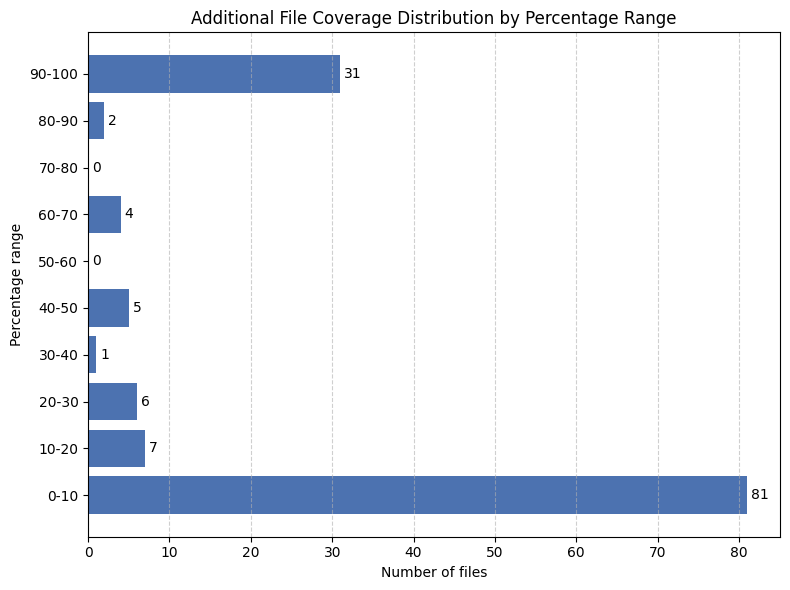

In [39]:
# Create percentage bins (intervals)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50",
          "50-60", "60-70", "70-80", "80-90", "90-100"]

# Create a new column with percentage ranges
summary_presence_additional["Percentage_Range"] = pd.cut(
    summary_presence_additional["Percentage"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count how many files fall in each range
distribution = summary_presence_additional["Percentage_Range"].value_counts().sort_index()

# --- Horizontal bar chart ---
plt.figure(figsize=(8,6))
bars = plt.barh(distribution.index, distribution.values, color="#4C72B0")
plt.xlabel("Number of files")
plt.ylabel("Percentage range")
plt.title("Additional File Coverage Distribution by Percentage Range")

# Add value labels at the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,               # X position (just beyond bar end)
        bar.get_y() + bar.get_height()/2,    # Y position (vertically centered)
        str(int(bar.get_width())),           # value label
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [40]:
summary_presence_additional.loc[summary_presence_additional['Percentage']>=90]

,Docs,Count,Percentage,Percentage_rounded,Percentage_Range
67,Informed_Consent_Tracking_Log_12Sep2025.csv,1056,100.000000,100.0,90-100
140,Hopkins_Verbal_Learning_Test_-_Revised_12Sep20...,1056,100.000000,100.0,90-100
139,State-Trait_Anxiety_Inventory_12Sep2025.csv,1056,100.000000,100.0,90-100
143,Cognitive_Categorization_12Sep2025.csv,1056,100.000000,100.0,90-100
55,Documentation_of_Informed_Consent_12Sep2025.csv,1056,100.000000,100.0,90-100
129,Primary_Clinical_Diagnosis_12Sep2025.csv,1056,100.000000,100.0,90-100
127,PD_Diagnosis_History_12Sep2025.csv,1056,100.000000,100.0,90-100
126,Other_Clinical_Features_12Sep2025.csv,1056,100.000000,100.0,90-100
141,Lexical_Fluency_12Sep2025.csv,1055,99.905303,100.0,90-100
138,QUIP-Current-Short_12Sep2025.csv,1055,99.905303,100.0,90-100
